# MNIST 次元削減の復元精度・プライバシー攻撃 実験

このノートブックでは、`dimensionality_reduction.py` と `anchor_utils.py` を用いて、
次元削減後の表現から元の特徴量をどの程度復元できるか、および将来的なプライバシー攻撃の実験用の枠組みを用意します。

基本設定は `base_config` で与えられた MNIST 用の設定を使用します。


# 局所流出

In [1]:
import numpy as np

In [2]:
# ノートブックの最初でリポジトリ直下に移動
import os
from pathlib import Path

repo_root = Path.cwd()
if not (repo_root / "input").exists():
    for p in repo_root.parents:
        if (p / "input").exists():
            repo_root = p
            break

os.chdir(repo_root)
print("CWD:", os.getcwd())


CWD: /Users/suetake/git-repos/takano_labo/dca


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def show_original_vs_recon(X_true, X_recon, n=10, y=None, labels=None):
    """
    X_true, X_recon: (N, 784)
    y:              (N,)  元のラベル（任意）
    labels:         ラベルのリストを指定したら、その順で最大5個だけ可視化
    """
    if labels is not None and y is not None:
        # ラベル順に最大5個だけ
        labels = list(labels)[:5]
        fig, axes = plt.subplots(2, len(labels), figsize=(1.5*len(labels), 3))
        for i, lab in enumerate(labels):
            idx_candidates = np.where(y == lab)[0]
            if len(idx_candidates) == 0:
                # そのラベルが無ければ空白
                axes[0, i].axis("off")
                axes[1, i].axis("off")
                axes[0, i].set_title(f"{lab}(none)")
                continue
            k = idx_candidates[0]

            orig = X_true[k].reshape(28, 28)
            recon = X_recon[k].reshape(28, 28)

            axes[0, i].imshow(orig, cmap="gray")
            axes[0, i].axis("off")
            axes[0, i].set_title(f"orig {lab}")

            axes[1, i].imshow(recon, cmap="gray")
            axes[1, i].axis("off")
            axes[1, i].set_title("recon")
        plt.tight_layout()
        plt.show()
        return

    # それ以外（labels 指定なし）の場合はランダムに n 個
    idx = np.random.choice(len(X_true), size=n, replace=False)
    fig, axes = plt.subplots(2, n, figsize=(1.5*n, 3))
    for i, k in enumerate(idx):
        orig = X_true[k].reshape(28, 28)
        recon = X_recon[k].reshape(28, 28)

        axes[0, i].imshow(orig, cmap="gray")
        axes[0, i].axis("off")
        axes[0, i].set_title("orig")

        axes[1, i].imshow(recon, cmap="gray")
        axes[1, i].axis("off")
        axes[1, i].set_title("recon")

    plt.tight_layout()
    plt.show()



In [4]:
from config.config import Config

base_config_dict = {
    "name": "tutorial_mnist",
    "dataset": "mnist",
    "y_name": "target",
    "num_institution_user": 1200,
    "data_distribution": "even",
    "anchor_method": "smote",
    "num_anchor_data": 500,
    "dim_intermediate": 600,
    "F_type": "svd",
    "seed": 42,
    "inter_normalization": False,
    "spill_num": 100,
    "preprocess":False,
}

base_config = Config(**base_config_dict)


In [5]:
from sklearn.metrics import pairwise_distances

def select_leak_random(A, A_tilde, spill_num, rng):
    spill_num = min(spill_num, A.shape[0])
    idx_leak = rng.choice(A.shape[0], size=spill_num, replace=False)
    return idx_leak, A[idx_leak], A_tilde[idx_leak]


def select_leak_local(A, A_tilde, X, y, a_label, spill_num):
    spill_num = min(spill_num, A.shape[0])
    Xa = X[y == a_label]
    dist_mat = pairwise_distances(A, Xa, metric="euclidean")
    min_dists_to_a = dist_mat.min(axis=1)
    idx_sorted = np.argsort(min_dists_to_a)
    idx_leak = idx_sorted[:spill_num]
    return idx_leak, A[idx_leak], A_tilde[idx_leak]


def select_leak_even(A, A_tilde, X, y, spill_num, rng):
    spill_num = min(spill_num, A.shape[0])

    # 近傍訓練データのラベルでアンカーにラベル付け
    D_anchor_train = pairwise_distances(A, X, metric="euclidean")
    nearest_idx = np.argmin(D_anchor_train, axis=1)
    anchor_labels = y[nearest_idx]

    labels = np.unique(y)
    L = len(labels)
    base_per_label = spill_num // L

    idx_leak_list = []
    for c in labels:
        anchor_idx_c = np.where(anchor_labels == c)[0]
        if len(anchor_idx_c) == 0:
            continue
        n_pick = min(base_per_label, len(anchor_idx_c))
        if n_pick > 0:
            idx_leak_list.append(rng.choice(anchor_idx_c, size=n_pick, replace=False))

    chosen = np.concatenate(idx_leak_list) if idx_leak_list else np.array([], dtype=int)
    remaining_needed = spill_num - len(chosen)
    if remaining_needed > 0:
        all_idx = np.arange(A.shape[0])
        remaining_pool = np.setdiff1d(all_idx, chosen)
        extra = rng.choice(
            remaining_pool,
            size=min(remaining_needed, len(remaining_pool)),
            replace=False,
        )
        idx_leak_list.append(extra)

    idx_leak = np.concatenate(idx_leak_list) if idx_leak_list else np.array([], dtype=int)
    return idx_leak, A[idx_leak], A_tilde[idx_leak]


def select_leak(A, A_tilde, X, y, a_label, cfg, rng):
    """cfg.spill_type に応じて leak アンカーを選ぶ統一インターフェース。"""
    spill_num = int(cfg.spill_num)
    if cfg.spill_type == "random":
        return select_leak_random(A, A_tilde, spill_num, rng)
    elif cfg.spill_type == "local":
        return select_leak_local(A, A_tilde, X, y, a_label, spill_num)
    elif cfg.spill_type == "even":
        return select_leak_even(A, A_tilde, X, y, spill_num, rng)
    else:
        # デフォルトは random
        return select_leak_random(A, A_tilde, spill_num, rng)


In [6]:

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor


def reconstruct_linear_pinv_centered(A_tilde_leak, A_leak, X_tilde):
    Z = np.asarray(A_tilde_leak, float)
    X = np.asarray(A_leak, float)

    Z_mean = Z.mean(axis=0, keepdims=True)
    X_mean = X.mean(axis=0, keepdims=True)
    Zc = Z - Z_mean
    Xc = X - X_mean

    W_c, *_ = np.linalg.lstsq(Zc, Xc, rcond=None)
    X_rec = (X_tilde - Z_mean) @ W_c + X_mean
    return X_rec, W_c, Z_mean, X_mean


def reconstruct_linear_ridge(A_tilde_leak, A_leak, X_tilde, lam=1e-3):
    """Z @ W ≈ X_target を ridge で学習し、X_tilde から復元する（中心化付き）。"""
    Z = np.asarray(A_tilde_leak, float)  # (n_leak, k)
    X = np.asarray(A_leak, float)        # (n_leak, d)

    # 1. リークアンカーの統計だけで中心化
    Z_mean = Z.mean(axis=0, keepdims=True)   # (1, k)
    X_mean = X.mean(axis=0, keepdims=True)   # (1, d)
    Zc = Z - Z_mean
    Xc = X - X_mean

    # 2. 中心化後の ridge 解
    ZTZ = Zc.T @ Zc
    k = ZTZ.shape[0]
    W = np.linalg.solve(
        ZTZ + lam * np.eye(k),
        Zc.T @ Xc,
    )  # (k, d)

    # 3. 任意の X_tilde を復元（同じ中心でシフト）
    X_rec = (X_tilde - Z_mean) @ W + X_mean
    return X_rec, W


def reconstruct_mlp(A_tilde_leak, A_leak, X_tilde, cfg):
    Z = np.asarray(A_tilde_leak, float)
    X = np.asarray(A_leak, float)

    # 入力側: 平均0（＋スケーリング）は従来通り
    scaler_z = StandardScaler()
    Z_train = scaler_z.fit_transform(Z)

    # 出力側: 平均を引いて学習し、あとで戻す
    X_mean = X.mean(axis=0, keepdims=True)
    Xc = X - X_mean

    mlp = MLPRegressor(
        hidden_layer_sizes=(256,),
        activation="relu",
        solver="adam",
        max_iter=2000,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=10,
        random_state=int(cfg.seed),
    )
    mlp.fit(Z_train, Xc)

    Z_all = scaler_z.transform(X_tilde)
    X_rec_c = mlp.predict(Z_all)
    X_rec_mlp = X_rec_c + X_mean
    return X_rec_mlp, mlp


def reconstruct_procrustes_pinv_style(A_tilde_leak, A_leak, X_tilde):
    """
    pinv と同じペア (Z, X_target) = (A_tilde_leak, A_leak) を使い、
    Z -> X の写像を「直交＋平行移動」制約付きで学習する。
    """
    Z = np.asarray(A_tilde_leak, float)   # (n_leak, k)
    X = np.asarray(A_leak, float)         # (n_leak, d)

    # 1. 両方をサンプル平均で中心化
    Z_mean = Z.mean(axis=0, keepdims=True)    # (1, k)
    X_mean = X.mean(axis=0, keepdims=True)    # (1, d)
    Zc = Z - Z_mean
    Xc = X - X_mean

    # 2. 直交 Procrustes: min_W ||Zc W - Xc||_F,  W^T W = I
    #    近似解: M = Zc^T Xc に対し SVD -> W_ortho = U V^T
    M = Zc.T @ Xc                         # (k, d)
    U, _, Vt = np.linalg.svd(M, full_matrices=False)
    W_ortho = U @ Vt                      # (k, d), 列がほぼ直交

    # 3. 任意の X_tilde に対する復元
    #    Z ≈ (X_tilde - Z_mean) とみなして
    X_rec = (X_tilde - Z_mean) @ W_ortho + X_mean
    return X_rec, W_ortho, Z_mean, X_mean

def reconstruct_pinv_orth(A_tilde_leak, A_leak, X_tilde):
    """
    A_tilde ≈ (A - mu) F を仮定し、
    (A_leak, A_tilde_leak) から F と mu を最小二乗で推定。
    復元は F の擬似逆 ≈ F^T を用いて x̂ = X_tilde F^T + mu で行う。
    （直交射影は行わない）
    """
    A = np.asarray(A_leak, float)         # (n_leak, d)
    Z = np.asarray(A_tilde_leak, float)   # (n_leak, k)

    # 1. 平均で中心化
    mean_A = A.mean(axis=0, keepdims=True)   # (1, d)
    mean_Z = Z.mean(axis=0, keepdims=True)   # (1, k)
    A_c = A - mean_A
    Z_c = Z - mean_Z

    # 2. A_c F ≈ Z_c を最小二乗で解いて F_hat を推定（d -> k）
    #    A_c: (n, d), Z_c: (n, k) => F_hat: (d, k)
    F_hat, *_ = np.linalg.lstsq(A_c, Z_c, rcond=None)

    # 3. 平行移動 mu を推定:
    #    Z ≈ (A - mu) F_hat なので mean_Z ≈ (mean_A - mu) F_hat
    #    => mu ≈ mean_A - mean_Z F_hat^T
    mu_hat = (mean_A - mean_Z @ F_hat.T).ravel()   # (d,)

    # 4. 任意の X_tilde を復元: x̂ = X_tilde F_hat^T + mu_hat
    X_rec = X_tilde @ F_hat.T + mu_hat
    return X_rec, F_hat, mu_hat

def reconstruct_pinv_not_orth(A_tilde_leak, A_leak, X_tilde):
    """
    A_tilde ≈ (A - mu) F を仮定し、
    (A_leak, A_tilde_leak) から F と mu を最小二乗で推定。
    直交性は仮定せず、F の擬似逆 F^+ を用いて
    x̂ = X_tilde F^+ + mu で復元する。
    """
    A = np.asarray(A_leak, float)         # (n_leak, d)
    Z = np.asarray(A_tilde_leak, float)   # (n_leak, k)

    # 1. 平均で中心化
    mean_A = A.mean(axis=0, keepdims=True)   # (1, d)
    mean_Z = Z.mean(axis=0, keepdims=True)   # (1, k)
    A_c = A - mean_A
    Z_c = Z - mean_Z

    # 2. A_c F ≈ Z_c を最小二乗で解いて F_hat を推定（d -> k）
    #    A_c: (n, d), Z_c: (n, k) => F_hat: (d, k)
    F_hat, *_ = np.linalg.lstsq(A_c, Z_c, rcond=None)

    # 2.5. F_hat の擬似逆を計算（直交性は仮定しない）
    F_hat_pinv = np.linalg.pinv(F_hat)       # (k, d)

    # 3. 平行移動 mu を推定:
    #    Z ≈ (A - mu) F_hat なので mean_Z ≈ (mean_A - mu) F_hat
    #    (mean_A - mu) ≈ mean_Z F_hat^+ から mu ≈ mean_A - mean_Z F_hat^+
    mu_hat = (mean_A - mean_Z @ F_hat_pinv).ravel()   # (d,)

    # 4. 任意の X_tilde を復元: x̂ = X_tilde F_hat^+ + mu_hat
    X_rec = X_tilde @ F_hat_pinv + mu_hat
    return X_rec, F_hat, mu_hat


In [7]:
def visualize_all_reconstructions(X, y, a_label, dataset_name, recon_dict):
    """
    recon_dict: {"pinv": X_rec_pinv, "mlp": X_rec_mlp, "proc": X_rec_proc, ...}
    """
    if dataset_name not in ("mnist", "fashion_mnist"):
        return

    mask_a = (y == a_label)
    mask_not_a = ~mask_a

    # ラベル a の可視化
    X_a = X[mask_a]
    if len(X_a) >= 5:
        for name, X_rec in recon_dict.items():
            print(f"[{name}] Label a = {a_label} の例")
            show_original_vs_recon(X_a, X_rec[mask_a], n=5)

    # ラベル not-a の可視化
    X_not_a = X[mask_not_a]
    y_not_a = y[mask_not_a]
    if len(X_not_a) >= 5:
        for name, X_rec in recon_dict.items():
            print(f"[{name}] Label not-a の例 ({name})")
            show_original_vs_recon(
                X_not_a, X_rec[mask_not_a], n=5, y=y_not_a, labels=[1, 2, 3, 4, 5]
            )


In [8]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error, accuracy_score

def compute_rmse_metrics(X, X_rec, mask_a, mask_not_a):
    def _rmse(X_true, X_hat, mask=None):
        if mask is not None:
            if not np.any(mask):
                return np.nan
            X_true = X_true[mask]
            X_hat = X_hat[mask]
        return float(np.sqrt(mean_squared_error(X_true, X_hat)))

    return {
        "all": _rmse(X, X_rec),
        "a": _rmse(X, X_rec, mask_a),
        "not_a": _rmse(X, X_rec, mask_not_a),
    }


def compute_acc_metrics(X, y, X_rec, mask_a, mask_not_a, cfg):
    clf = MLPClassifier(
        hidden_layer_sizes=(256,),
        activation="relu",
        solver="adam",
        max_iter=200,
        random_state=int(cfg.seed),
    )
    clf.fit(X, y)

    y_pred = clf.predict(X_rec)

    def _acc(y_true, y_pred, mask=None):
        if mask is not None:
            if not np.any(mask):
                return np.nan
            y_true = y_true[mask]
            y_pred = y_pred[mask]

        # # デバッグ: ラベル数/予測分布を確認
        # print(f"[counts] a={mask_a.sum()} not_a={mask_not_a.sum()}")
        # print(f"[pred counts all] {dict(zip(*np.unique(y_pred, return_counts=True)))}")
        # print(f"[pred counts a] {dict(zip(*np.unique(y_pred[mask_a], return_counts=True)))}")
        return float(accuracy_score(y_true, y_pred))

    return {
        "all": _acc(y, y_pred),
        "a": _acc(y, y_pred, mask_a),
        "not_a": _acc(y, y_pred, mask_not_a),
    }


In [9]:
from src import dimensionality_reduction
from src.institution_data_pipeline.load_data import load_data
from src.intermediate_expression import anchor_utils
import random
def run_anchor_local_leak_reconstruction(base_config) -> dict:
    # ---- config を Config に整形 ----
    if isinstance(base_config, Config):
        cfg = base_config
    elif isinstance(base_config, dict):
        cfg = Config(**base_config)
    else:
        cfg = Config(**vars(base_config))

    seed = int(cfg.seed)
    rng = np.random.default_rng(seed)
    np.random.seed(seed)
    random.seed(seed)

    def _sample_anchor_indices(anchor_labels: np.ndarray, num_anchor: int) -> np.ndarray:
        if len(anchor_labels) == 0:
            raise ValueError("Anchor pool is empty. Increase dataset size or adjust config.")
        if cfg.spill_type == "random":
            if len(anchor_labels) < num_anchor:
                raise ValueError(
                    f"Need {num_anchor} anchor samples but only {len(anchor_labels)} remain for 'random'."
                )
            return rng.choice(len(anchor_labels), size=num_anchor, replace=False)

        if cfg.spill_type == "local":
            target_label = getattr(cfg, "anchor_local_label", None)
            if target_label is None:
                target_label = np.min(anchor_labels)
            idx_local = np.where(anchor_labels == target_label)[0]
            if len(idx_local) < num_anchor:
                raise ValueError(
                    f"Need {num_anchor} samples for label {target_label} but only {len(idx_local)} available."
                )
            return rng.choice(idx_local, size=num_anchor, replace=False)

        if cfg.spill_type == "even":
            labels = np.unique(anchor_labels)
            if len(labels) == 0:
                raise ValueError("No labels available in anchor pool for 'even' sampling.")
            base = num_anchor // len(labels)
            remainder = num_anchor % len(labels)
            alloc = {label: base for label in labels}
            if remainder:
                extra_labels = rng.choice(labels, size=remainder, replace=False)
                for label in extra_labels:
                    alloc[label] += 1
            idx_list = []
            for label in labels:
                need = alloc[label]
                if need == 0:
                    continue
                idx_label = np.where(anchor_labels == label)[0]
                if len(idx_label) < need:
                    raise ValueError(
                        f"Need {need} samples for label {label} but only {len(idx_label)} available."
                    )
                idx_list.append(rng.choice(idx_label, size=need, replace=False))
            return np.concatenate(idx_list)

        raise ValueError(f"Unsupported spill_type: {cfg.spill_type}")

    # ---- データ読み込み & サブサンプル ----
    df_full = load_data(cfg)
    n_total = len(df_full)
    n_use = min(n_total, int(cfg.num_institution_user))
    num_anchor = int(cfg.num_anchor_data)

    if n_use <= 0:
        raise ValueError("num_institution_user must be positive.")
    if n_total < n_use + num_anchor:
        raise ValueError(
            "Not enough data rows to create disjoint institution and anchor splits. "
            f"Available={n_total}, required={n_use + num_anchor}."
        )

    idx_perm = rng.permutation(n_total)
    idx_user = idx_perm[:n_use]
    idx_anchor_pool = idx_perm[n_use:]

    df_sub = df_full.iloc[idx_user].reset_index(drop=True)
    df_anchor_pool = df_full.iloc[idx_anchor_pool].reset_index(drop=True)

    y = df_sub[cfg.y_name].to_numpy()
    X = df_sub.drop(columns=[cfg.y_name]).to_numpy(dtype=np.float32)

    # after df_sub/df_anchor_pool を作った直後くらいで
    print("[label counts] user:", df_sub[cfg.y_name].value_counts().to_dict())
    print("[label counts] anchor_pool:", df_anchor_pool[cfg.y_name].value_counts().to_dict())

    # anchor を選んだ後 (idx_anchor 決定後)
    # print("[label counts] anchor_selected:", dict(zip(*np.unique(anchor_y_pool[idx_anchor], return_counts=True))))

    # テストデータはこの関数では扱っていないので、必要なら load_data の戻り df_full から別途確認:
    # y_full = df_full[cfg.y_name]
    # print("[label counts] full:", y_full.value_counts().to_dict())


    # ラベル a
    labels = np.unique(y)
    a_label = labels[0]
    mask_a = (y == a_label)
    mask_not_a = ~mask_a

    # ---- 次元削減 ----
    projector = dimensionality_reduction.build_dimensionality_projector(
        X,
        n_components=int(cfg.dim_intermediate),
        F_type=cfg.F_type,
        seed=seed,
        config=cfg,
        y=y,
    )
    X_tilde = projector(X)

    # ---- アンカー生成 ----
    anchor_method = str(getattr(cfg, "anchor_method", "real")).lower()
    num_features = X.shape[1]

    if anchor_method == "real":
        anchor_X_pool = df_anchor_pool.drop(columns=[cfg.y_name]).to_numpy(dtype=np.float32)
        anchor_y_pool = df_anchor_pool[cfg.y_name].to_numpy()
        idx_anchor = _sample_anchor_indices(anchor_y_pool, num_anchor)
        A = anchor_X_pool[idx_anchor]
        anchor_labels = anchor_y_pool[idx_anchor]

    elif anchor_method in ("gaussian", "smote"):
        print
        smote_X = df_anchor_pool.drop(columns=[cfg.y_name]).to_numpy(dtype=np.float32)
        smote_y = df_anchor_pool[cfg.y_name].to_numpy()
        res = anchor_utils.produce_anchor(
            num_row=num_anchor,
            num_col=num_features,
            seed=cfg.seed,
            config=cfg,
            train_df=df_anchor_pool,
            Xs_train=[],
            Xs_test=[],
            ys_train=[],
            ys_test=[],
            smote_X=smote_X if anchor_method == "smote" else None,
            smote_y=smote_y if anchor_method == "smote" else None,
            include_public_anchor=True,
            return_labels=True,
        )
        if isinstance(res, tuple) and len(res) == 2:
            A, anchor_labels = res
        else:
            A = res
            anchor_labels = np.zeros(A.shape[0], dtype=float)
        idx_anchor = np.arange(len(A))

    else:
        raise ValueError(f"Unsupported anchor_method: {anchor_method}")

    A_tilde = projector(A)

    # 全アンカーが流出するケース
    A_leak = A
    A_tilde_leak = A_tilde
    idx_leak = np.arange(len(A_leak))

    # ---- 各種復元 ----
    X_rec_pinv, W_pinv, Z_mean, X_mean = reconstruct_linear_pinv_centered(
        A_tilde_leak, A_leak, X_tilde
    )
    X_rec_mlp, mlp      = reconstruct_mlp(A_tilde_leak, A_leak, X_tilde, cfg)
    X_rec_proc, W_ortho, Z_mean, X_mean = reconstruct_procrustes_pinv_style(
        A_tilde_leak, A_leak, X_tilde
    )
    X_rec_pinv_orth, F_hat, mu_hat = reconstruct_pinv_orth(
        A_tilde_leak, A_leak, X_tilde)

    X_rec_pinv_not_orth, F_hat, mu_hat = reconstruct_pinv_not_orth(
        A_tilde_leak, A_leak, X_tilde
    )

    methods = {
        "pinv": X_rec_pinv,
        "mlp": X_rec_mlp,
        "proc": X_rec_proc,
        "pinv_orth": X_rec_pinv_orth,
        "pinv_not_orth": X_rec_pinv_not_orth,
    }
    visualize_all_reconstructions(X, y, a_label, cfg.dataset, methods)

    # ---- 評価 ----
    rmse_pinv = compute_rmse_metrics(
        X, X_rec_pinv, mask_a, mask_not_a
    )
    rmse_pinv_all = rmse_pinv["all"]
    rmse_pinv_a = rmse_pinv["a"]
    rmse_pinv_not_a = rmse_pinv["not_a"]
    rmse_mlp = compute_rmse_metrics(
        X, X_rec_mlp, mask_a, mask_not_a
    )
    rmse_mlp_all = rmse_mlp["all"]
    rmse_mlp_a = rmse_mlp["a"]
    rmse_mlp_not_a = rmse_mlp["not_a"]
    rmse_proc = compute_rmse_metrics(
        X, X_rec_proc, mask_a, mask_not_a
    )
    rmse_proc_all = rmse_proc["all"]
    rmse_proc_a = rmse_proc["a"]
    rmse_proc_not_a = rmse_proc["not_a"]
    rmse_pinv_orth = compute_rmse_metrics(
        X, X_rec_pinv_orth, mask_a, mask_not_a
    )
    rmse_pinv_orth_all = rmse_pinv_orth["all"]
    rmse_pinv_orth_a = rmse_pinv_orth["a"]
    rmse_pinv_orth_not_a = rmse_pinv_orth["not_a"]
    rmse_pinv_not_orth = compute_rmse_metrics(
        X, X_rec_pinv_not_orth, mask_a, mask_not_a
    )
    rmse_pinv_not_orth_all = rmse_pinv_not_orth["all"]
    rmse_pinv_not_orth_a = rmse_pinv_not_orth["a"]
    rmse_pinv_not_orth_not_a = rmse_pinv_not_orth["not_a"]

    acc_pinv = compute_acc_metrics(
        X, y, X_rec_pinv, mask_a, mask_not_a, cfg
    )
    acc_pinv_all = acc_pinv["all"]
    acc_pinv_a = acc_pinv["a"]
    acc_pinv_not_a = acc_pinv["not_a"]
    acc_mlp = compute_acc_metrics(
        X, y, X_rec_mlp, mask_a, mask_not_a, cfg
    )
    acc_mlp_all = acc_mlp["all"]
    acc_mlp_a = acc_mlp["a"]
    acc_mlp_not_a = acc_mlp["not_a"]
    acc_proc = compute_acc_metrics(
        X, y, X_rec_proc, mask_a, mask_not_a, cfg
    )
    acc_proc_all = acc_proc["all"]
    acc_proc_a = acc_proc["a"]
    acc_proc_not_a = acc_proc["not_a"]
    acc_pinv_orth = compute_acc_metrics(
        X, y, X_rec_pinv_orth, mask_a, mask_not_a, cfg
    )
    acc_pinv_orth_all = acc_pinv_orth["all"]
    acc_pinv_orth_a = acc_pinv_orth["a"]
    acc_pinv_orth_not_a = acc_pinv_orth["not_a"]
    acc_pinv_not_orth = compute_acc_metrics(
        X, y, X_rec_pinv_not_orth, mask_a, mask_not_a, cfg
    )
    acc_pinv_not_orth_all = acc_pinv_not_orth["all"]
    acc_pinv_not_orth_a = acc_pinv_not_orth["a"]
    acc_pinv_not_orth_not_a = acc_pinv_not_orth["not_a"]

    def _fmt(x):
        try:
            return f"{float(x):.4f}"
        except Exception:
            return str(x)

    print(
        f"[anchor_local_leak] dataset={cfg.dataset}, F_type={cfg.F_type}, "
        f"dim={X_tilde.shape[1]}, anchors={len(A_leak)}, a_label={a_label}, spill_type={cfg.spill_type}"
    )
    print(f"  pseudo-inverse ACC   : all={_fmt(acc_pinv_all)}, a={_fmt(acc_pinv_a)}, not_a={_fmt(acc_pinv_not_a)}")
    print(f"  MLP ACC              : all={_fmt(acc_mlp_all)}, a={_fmt(acc_mlp_a)}, not_a={_fmt(acc_mlp_not_a)}")
    print(f"  Procrustes ACC       : all={_fmt(acc_proc_all)}, a={_fmt(acc_proc_a)}, not_a={_fmt(acc_proc_not_a)}")
    print(f"  pinv_orth ACC        : all={_fmt(acc_pinv_orth_all)}, a={_fmt(acc_pinv_orth_a)}, not_a={_fmt(acc_pinv_orth_not_a)}")
    print(f"  pinv_not_orth ACC    : all={_fmt(acc_pinv_not_orth_all)}, a={_fmt(acc_pinv_not_orth_a)}, not_a={_fmt(acc_pinv_not_orth_not_a)}")



    return {
        "rmse_pinv_all": rmse_pinv_all,
        "rmse_pinv_a": rmse_pinv_a,
        "rmse_pinv_not_a": rmse_pinv_not_a,
        "rmse_mlp_all": rmse_mlp_all,
        "rmse_mlp_a": rmse_mlp_a,
        "rmse_mlp_not_a": rmse_mlp_not_a,
        "rmse_proc_all": rmse_proc_all,
        "rmse_proc_a": rmse_proc_a,
        "rmse_proc_not_a": rmse_proc_not_a,
        "rmse_pinv_orth_all": rmse_pinv_orth_all,
        "rmse_pinv_orth_a": rmse_pinv_orth_a,
        "rmse_pinv_orth_not_a": rmse_pinv_orth_not_a,
        "rmse_pinv_not_orth_all": rmse_pinv_not_orth_all,
        "rmse_pinv_not_orth_a": rmse_pinv_not_orth_a,
        "rmse_pinv_not_orth_not_a": rmse_pinv_not_orth_not_a,
        "acc_pinv_all": acc_pinv_all,
        "acc_pinv_a": acc_pinv_a,
        "acc_pinv_not_a": acc_pinv_not_a,
        "acc_mlp_all": acc_mlp_all,
        "acc_mlp_a": acc_mlp_a,
        "acc_mlp_not_a": acc_mlp_not_a,
        "acc_proc_all": acc_proc_all,
        "acc_proc_a": acc_proc_a,
        "acc_proc_not_a": acc_proc_not_a,
        "acc_pinv_orth_all": acc_pinv_orth_all,
        "acc_pinv_orth_a": acc_pinv_orth_a,
        "acc_pinv_orth_not_a": acc_pinv_orth_not_a,
        "acc_pinv_not_orth_all": acc_pinv_not_orth_all,
        "acc_pinv_not_orth_a": acc_pinv_not_orth_a,
        "acc_pinv_not_orth_not_a": acc_pinv_not_orth_not_a,
    }


In [10]:

from itertools import product
import pandas as pd
from config.config import Config

def run_anchor_local_leak_grid(base_config_dict: dict):
    """
    base_config_dict の各キーにリストを入れておくと、
    その直積（全組み合わせ）で Config を作り、
    run_anchor_local_leak_reconstruction(Config) を全パターン実行する。
    戻り値: 結果をまとめた DataFrame
    """
    keys = list(base_config_dict.keys())
    value_lists = [
        (v if isinstance(v, (list, tuple)) else [v])
        for v in (base_config_dict[k] for k in keys)
    ]

    records = []

    for values in product(*value_lists):
        cfg_kwargs = {k: v for k, v in zip(keys, values)}
        cfg = Config(**cfg_kwargs)

        res = run_anchor_local_leak_reconstruction(cfg)  # さっき作った関数

        record = dict(cfg_kwargs)
        # record["rmse_pinv"] = res["rmse_pinv_all"]
        # record["rmse_pinv_a"] = res["rmse_pinv_a"]
        # record["rmse_pinv_not_a"] = res["rmse_pinv_not_a"]
        # record["rmse_mlp"] = res["rmse_mlp_all"]
        # record["rmse_mlp_a"] = res["rmse_mlp_a"]
        # record["rmse_mlp_not_a"] = res["rmse_mlp_not_a"]
        
        # ここから accuracy
        record["acc_pinv"] = res["acc_pinv_all"]
        #record["acc_pinv_a"] = res["acc_pinv_a"]
        #record["acc_pinv_not_a"] = res["acc_pinv_not_a"]
        record["acc_mlp"] = res["acc_mlp_all"]
        #record["acc_mlp_a"] = res["acc_mlp_a"]
        #record["acc_mlp_not_a"] = res["acc_mlp_not_a"]
        record["acc_proc"] = res["acc_proc_all"]
        #record["acc_proc_a"] = res["acc_proc_a"]
        #record["acc_proc_not_a"] = res["acc_proc_not_a"]
        record["acc_pinv_orth"] = res["acc_pinv_orth_all"]
        records.append(record)

    return pd.DataFrame(records)

[label counts] user: {8: 116, 9: 107, 4: 106, 3: 105, 1: 104, 0: 103, 6: 101, 7: 97, 2: 89, 5: 72}
[label counts] anchor_pool: {1: 7773, 7: 7196, 3: 7036, 2: 6901, 9: 6851, 0: 6800, 6: 6775, 4: 6718, 8: 6709, 5: 6241}
[pinv] Label a = 0 の例


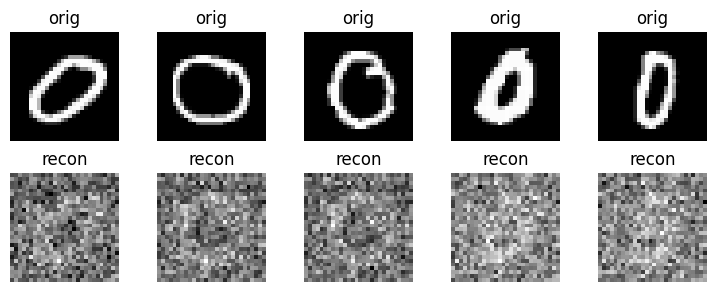

[mlp] Label a = 0 の例


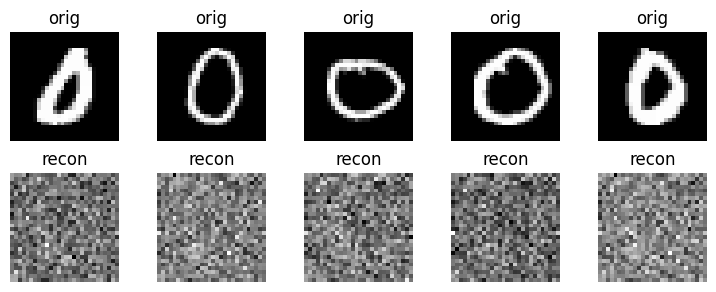

[proc] Label a = 0 の例


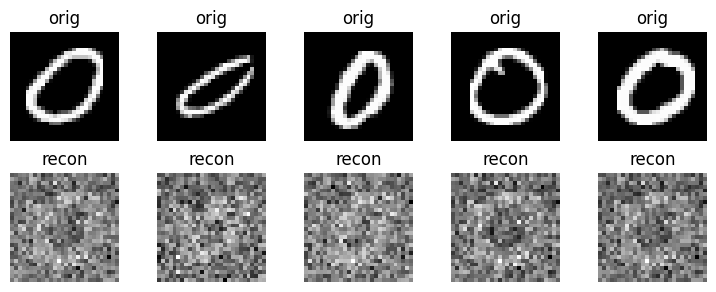

[pinv_orth] Label a = 0 の例


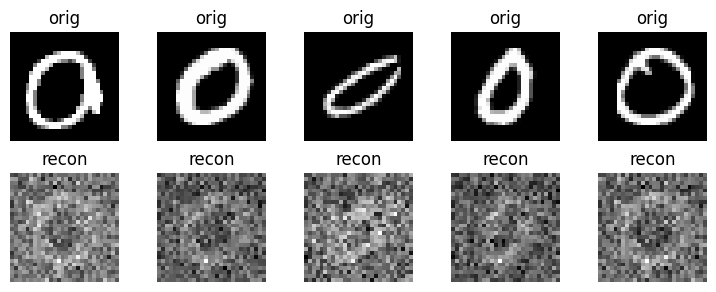

[pinv_not_orth] Label a = 0 の例


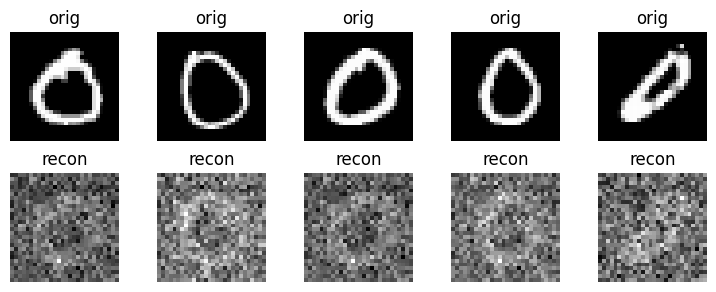

[pinv] Label not-a の例 (pinv)


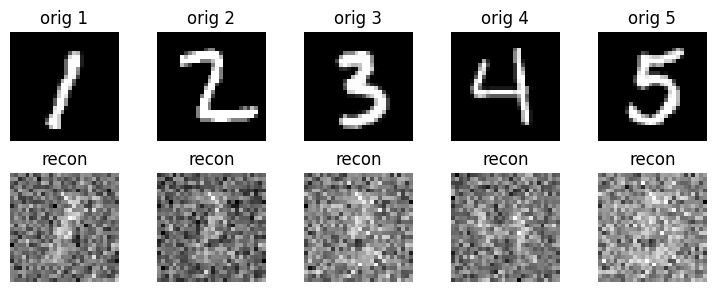

[mlp] Label not-a の例 (mlp)


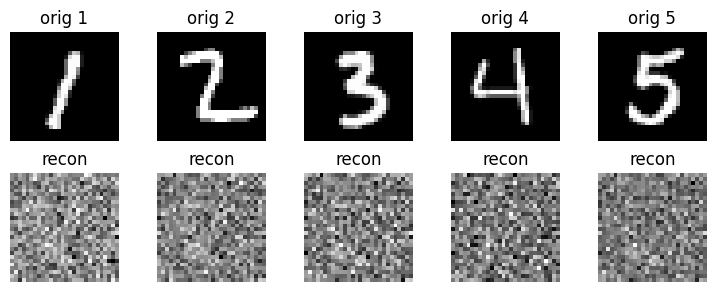

[proc] Label not-a の例 (proc)


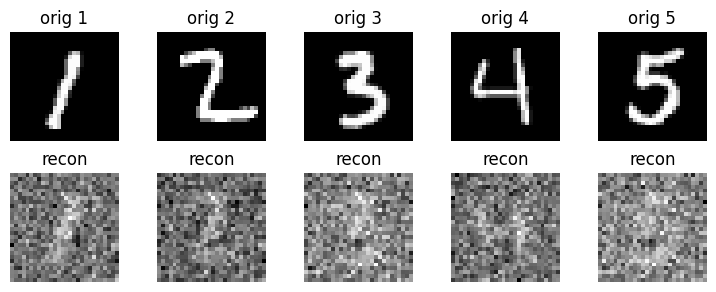

[pinv_orth] Label not-a の例 (pinv_orth)


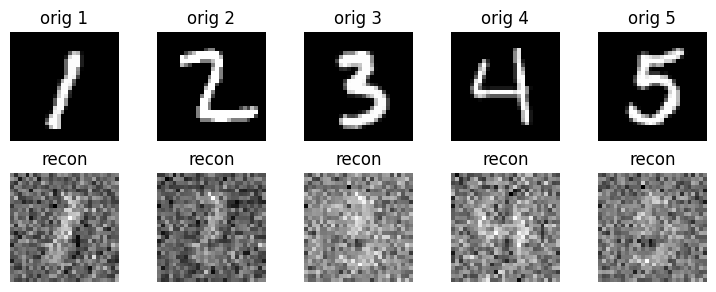

[pinv_not_orth] Label not-a の例 (pinv_not_orth)


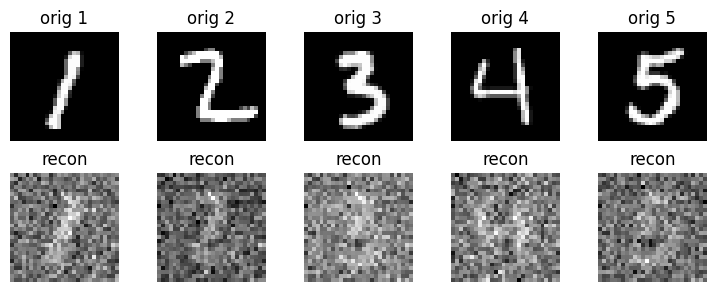

[anchor_local_leak] dataset=mnist, F_type=diffspan_orth, dim=10, anchors=200, a_label=0, spill_type=None
  pseudo-inverse ACC   : all=0.3740, a=0.1650, not_a=0.3980
  MLP ACC              : all=0.2340, a=0.2427, not_a=0.2330
  Procrustes ACC       : all=0.3750, a=0.2233, not_a=0.3924
  pinv_orth ACC        : all=0.4110, a=0.4272, not_a=0.4091
  pinv_not_orth ACC    : all=0.4070, a=0.3883, not_a=0.4091
[label counts] user: {8: 116, 9: 107, 4: 106, 3: 105, 1: 104, 0: 103, 6: 101, 7: 97, 2: 89, 5: 72}
[label counts] anchor_pool: {1: 7773, 7: 7196, 3: 7036, 2: 6901, 9: 6851, 0: 6800, 6: 6775, 4: 6718, 8: 6709, 5: 6241}
[pinv] Label a = 0 の例


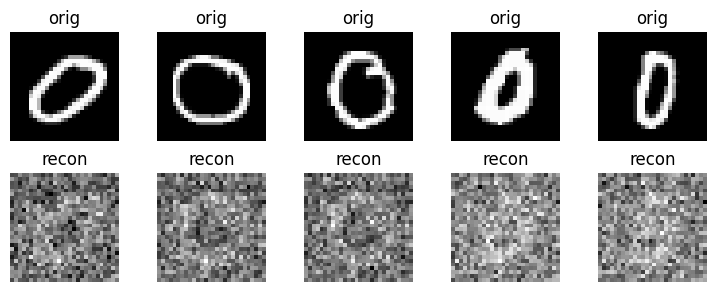

[mlp] Label a = 0 の例


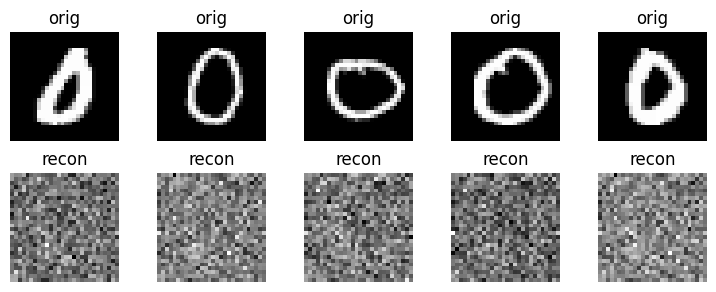

[proc] Label a = 0 の例


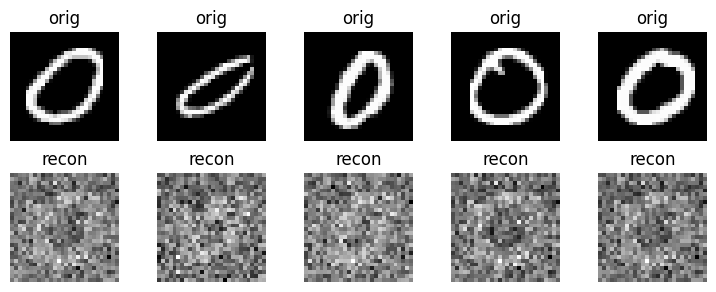

[pinv_orth] Label a = 0 の例


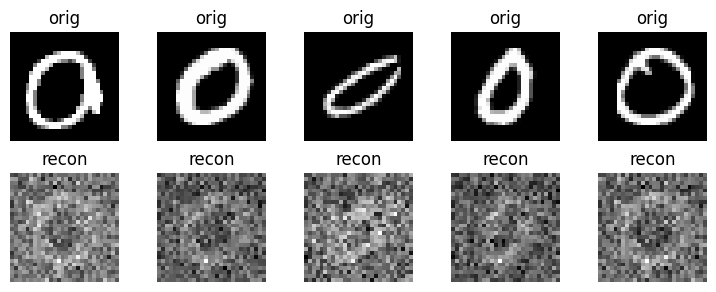

[pinv_not_orth] Label a = 0 の例


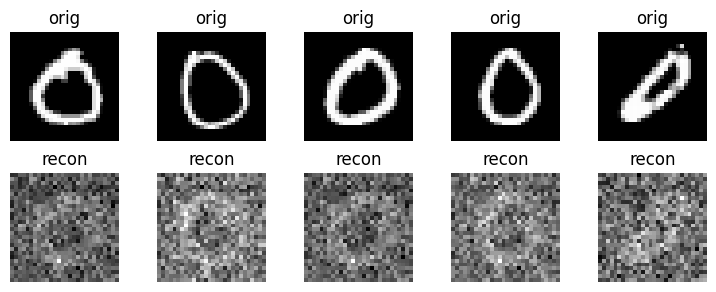

[pinv] Label not-a の例 (pinv)


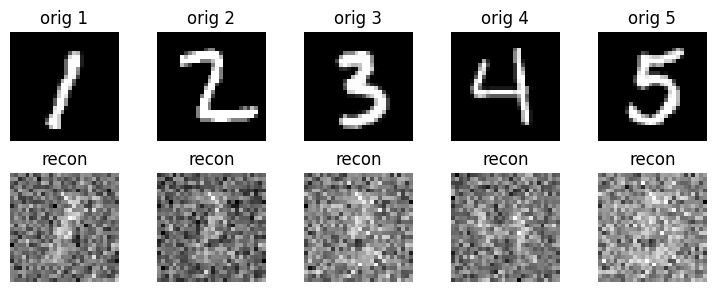

[mlp] Label not-a の例 (mlp)


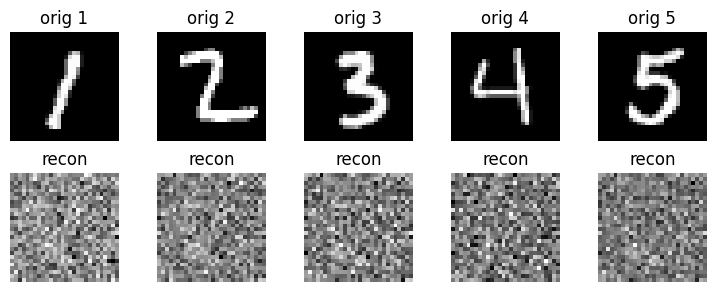

[proc] Label not-a の例 (proc)


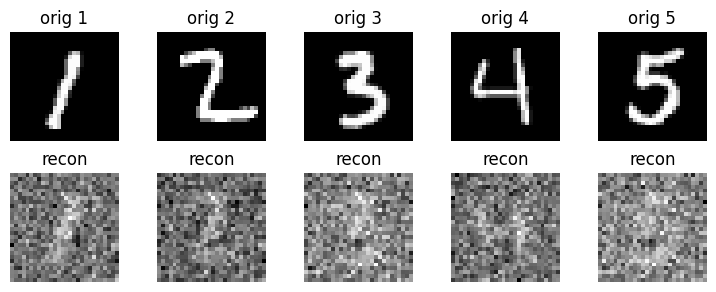

[pinv_orth] Label not-a の例 (pinv_orth)


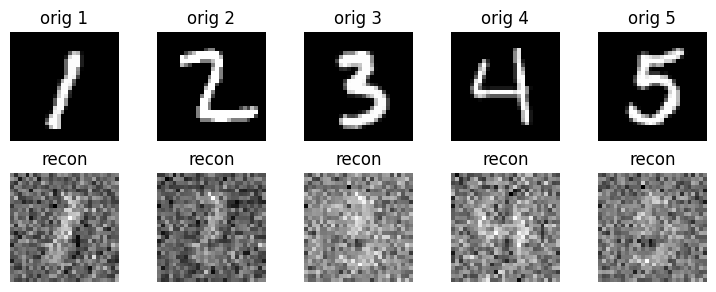

[pinv_not_orth] Label not-a の例 (pinv_not_orth)


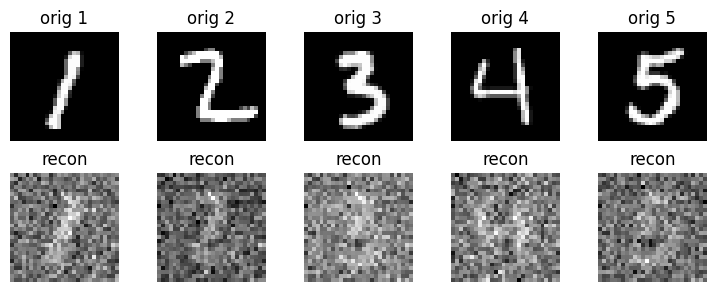

[anchor_local_leak] dataset=mnist, F_type=svd, dim=10, anchors=200, a_label=0, spill_type=None
  pseudo-inverse ACC   : all=0.3740, a=0.1650, not_a=0.3980
  MLP ACC              : all=0.2340, a=0.2427, not_a=0.2330
  Procrustes ACC       : all=0.3750, a=0.2233, not_a=0.3924
  pinv_orth ACC        : all=0.4110, a=0.4272, not_a=0.4091
  pinv_not_orth ACC    : all=0.4070, a=0.3883, not_a=0.4091


In [15]:
from config.config import Config

base_config_dict = {
    "name": ["tutorial_mnist"],
    "dataset": [
    #"fashion_mnist",
    "mnist",
    #"mnist_1248",
    #"mice",
    #"statlog",
    #"qsar",
    #"digits",
    #"breast_cancer",
    #"adult",
    #"glass", 
    #"seeds", 
    #"letter_recognition",
    #"wine_quality",
    #"har",
    #"cifar10",
    #'3D_gaussian_clusters',
    #"concentric_three_circles",
    #"iris",
    #"ecoli",
    #"vowel"
    #"medmnist_3",
    #"medmnist_5"
],
    #"spill_type": ["local"], # "local", "even", 
    "y_name": ["target"],
    "num_institution_user": [1000],
    "data_distribution": ["even"],
    "anchor_method": ["gaussian"], # "smote"
    "num_anchor_data": [200],
    "dim_intermediate": [10],
    #"spill_num": [300],
    "F_type": ["diffspan_orth", "svd"], #   "ae", "kernel_pca_self_tuning", "umap"
    "inter_normalization": [False],
    "preprocess":[False],
    "smote_ratio": [0],
    "gamma_ratio": [1.0],
    "seed":[i for i in range(1)],
    "visualize_rec": [False],
    "visualize_method_list": [["pinv_not_a", "mlp_a", "pinv_orth_not_a", "pinv_not_orth_not_a"]],
}

df_results = run_anchor_local_leak_grid(base_config_dict)
df_results
# 適当な CSV 出力
df_results.to_csv("anchor_local_leak_results.csv", index=False)


[label counts] user: {1: 14, 0: 12, 7: 12, 8: 12, 2: 11, 4: 11, 9: 10, 6: 9, 3: 5, 5: 4}
[label counts] anchor_pool: {1: 7863, 7: 7281, 3: 7136, 2: 6979, 9: 6948, 0: 6891, 6: 6867, 8: 6813, 4: 6813, 5: 6309}
[pinv] Label a = 0 の例


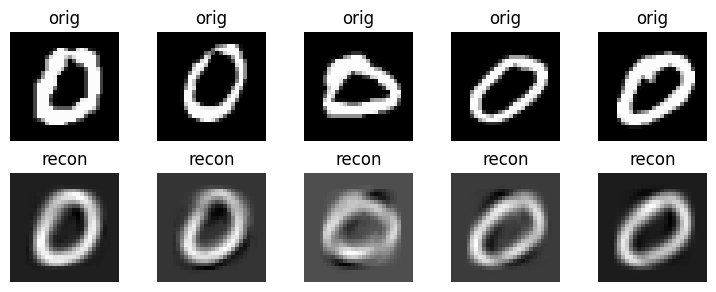

[mlp] Label a = 0 の例


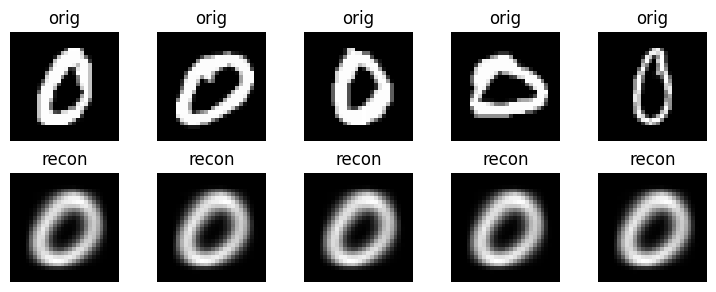

[proc] Label a = 0 の例


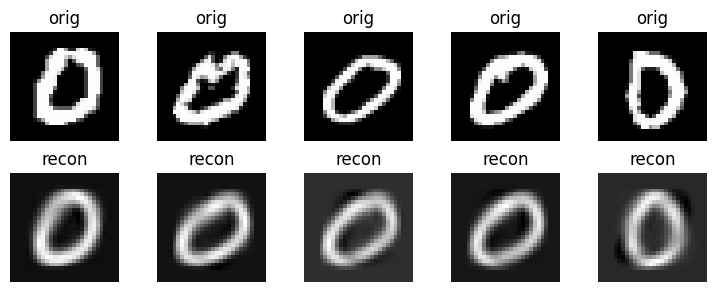

[pinv_orth] Label a = 0 の例


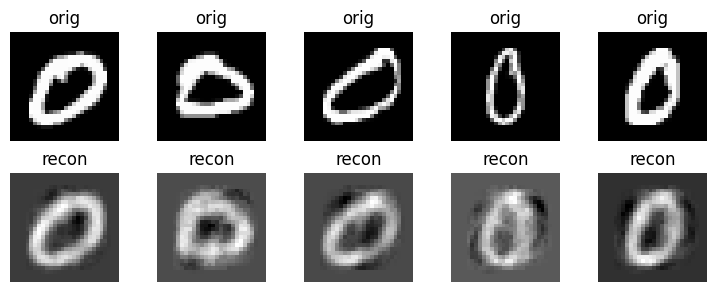

[pinv_not_orth] Label a = 0 の例


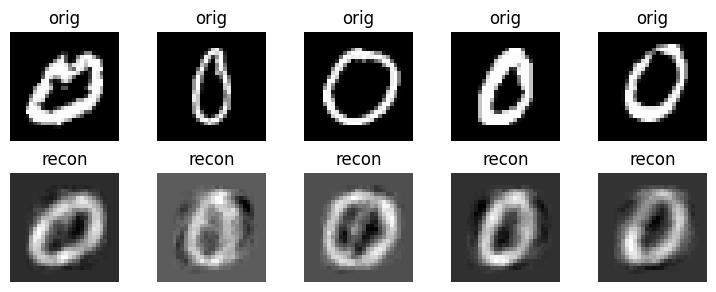

[pinv] Label not-a の例 (pinv)


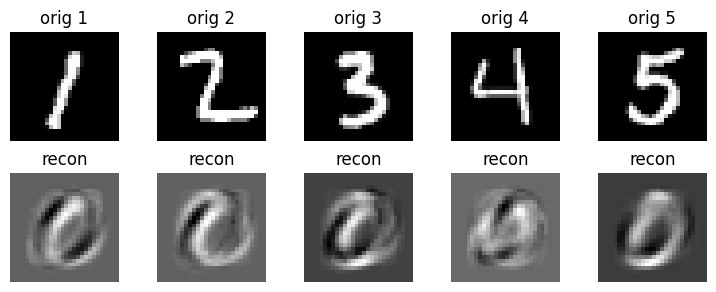

[mlp] Label not-a の例 (mlp)


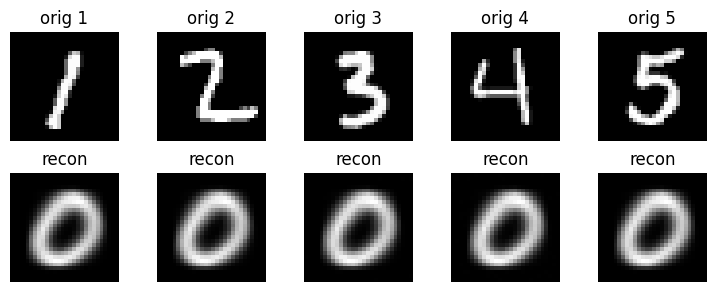

[proc] Label not-a の例 (proc)


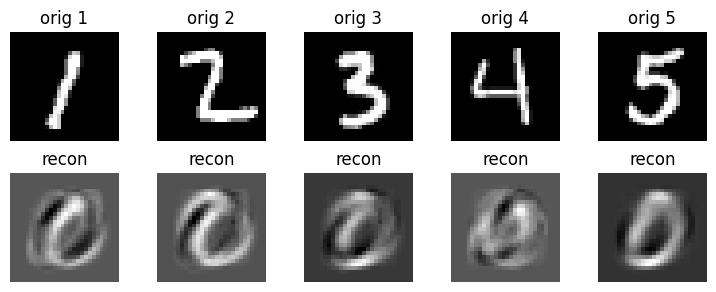

[pinv_orth] Label not-a の例 (pinv_orth)


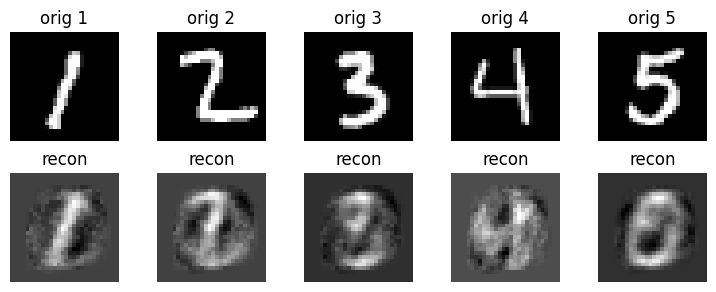

[pinv_not_orth] Label not-a の例 (pinv_not_orth)


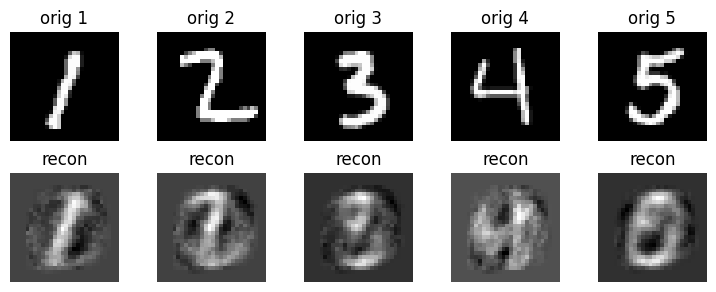

[anchor_local_leak] dataset=mnist, F_type=svd, dim=10, anchors=300, a_label=0, spill_type=local
  pseudo-inverse ACC   : all=0.4800, a=0.8333, not_a=0.4318
  MLP ACC              : all=0.1200, a=1.0000, not_a=0.0000
  Procrustes ACC       : all=0.5200, a=0.9167, not_a=0.4659
  pinv_orth ACC        : all=0.6900, a=0.8333, not_a=0.6705
  pinv_not_orth ACC    : all=0.6900, a=0.8333, not_a=0.6705
[label counts] user: {1: 14, 0: 12, 7: 12, 8: 12, 2: 11, 4: 11, 9: 10, 6: 9, 3: 5, 5: 4}
[label counts] anchor_pool: {1: 7863, 7: 7281, 3: 7136, 2: 6979, 9: 6948, 0: 6891, 6: 6867, 8: 6813, 4: 6813, 5: 6309}
UMAP seed: 0


/Users/suetake/git-repos/takano_labo/dca/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[pinv] Label a = 0 の例


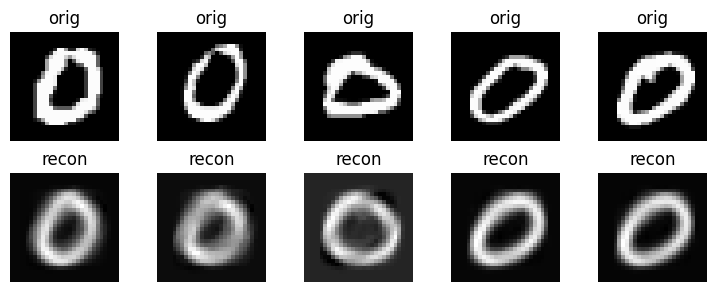

[mlp] Label a = 0 の例


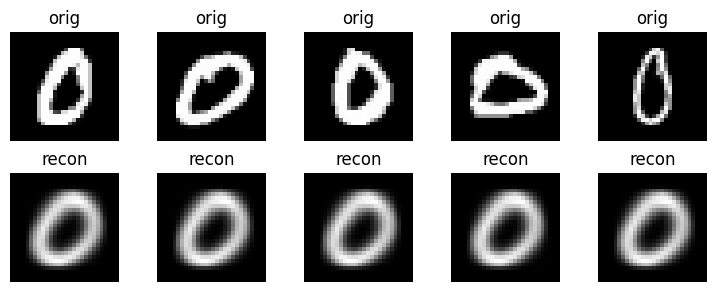

[proc] Label a = 0 の例


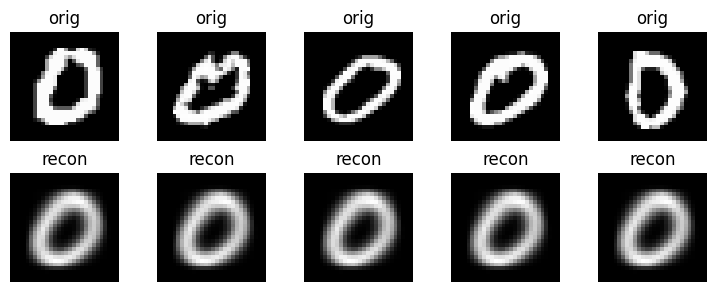

[pinv_orth] Label a = 0 の例


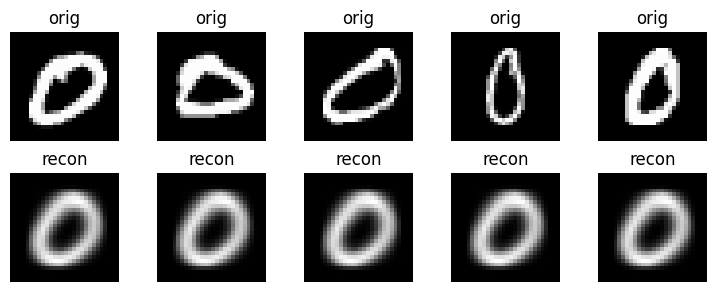

[pinv_not_orth] Label a = 0 の例


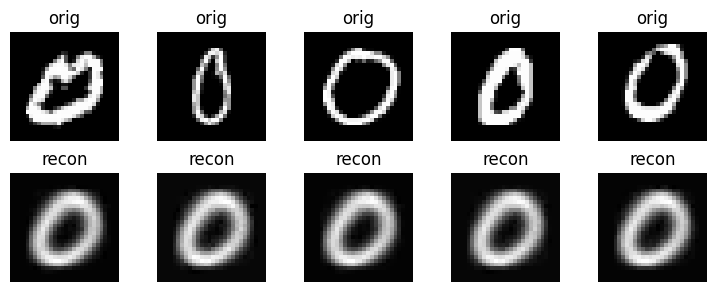

[pinv] Label not-a の例 (pinv)


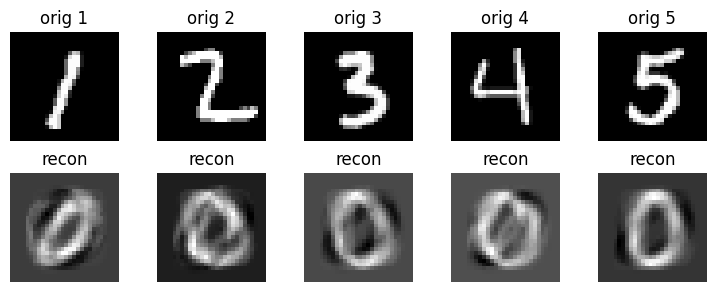

[mlp] Label not-a の例 (mlp)


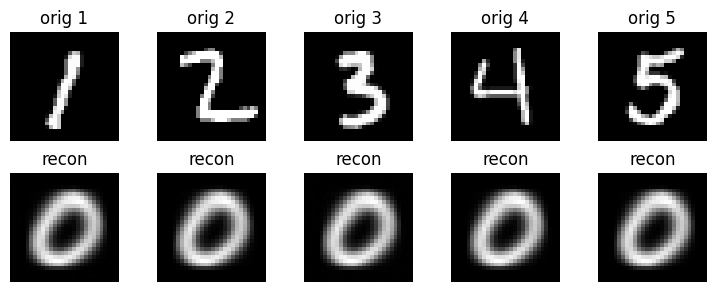

[proc] Label not-a の例 (proc)


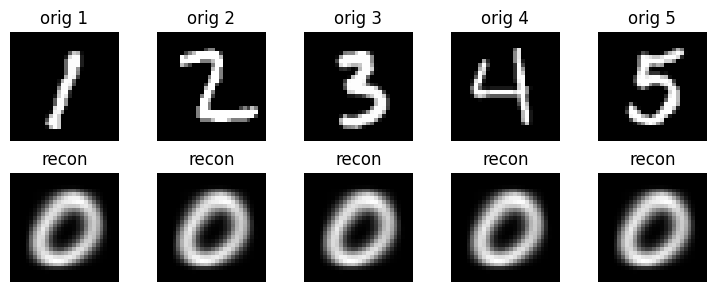

[pinv_orth] Label not-a の例 (pinv_orth)


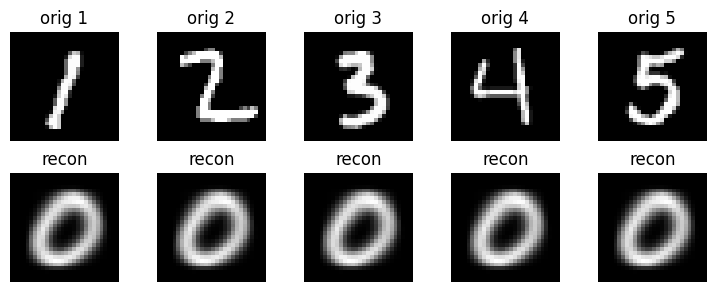

[pinv_not_orth] Label not-a の例 (pinv_not_orth)


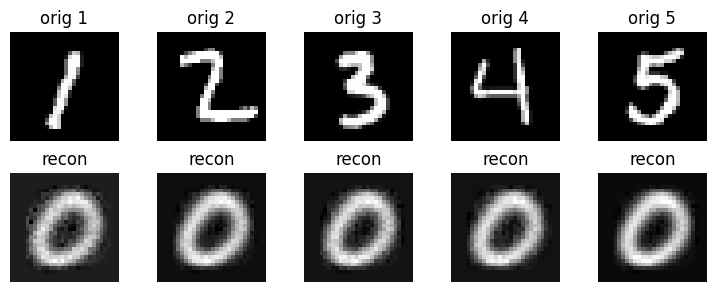

[anchor_local_leak] dataset=mnist, F_type=umap, dim=10, anchors=300, a_label=0, spill_type=local
  pseudo-inverse ACC   : all=0.2100, a=0.9167, not_a=0.1136
  MLP ACC              : all=0.1200, a=1.0000, not_a=0.0000
  Procrustes ACC       : all=0.1200, a=1.0000, not_a=0.0000
  pinv_orth ACC        : all=0.1200, a=1.0000, not_a=0.0000
  pinv_not_orth ACC    : all=0.1200, a=1.0000, not_a=0.0000


In [14]:
from config.config import Config

base_config_dict = {
    "name": ["tutorial_mnist"],
    "dataset": [
    #"fashion_mnist",
    "mnist",
    #"mnist_1248",
    #"mice",
    #"statlog",
    #"qsar",
    #"digits",
    #"breast_cancer",
    #"adult",
    #"glass", 
    #"seeds", 
    #"letter_recognition",
    #"wine_quality",
    #"har",
    #"cifar10",
    #'3D_gaussian_clusters',
    #"concentric_three_circles",
    #"iris",
    #"ecoli",
    #"vowel"
    #"medmnist_3",
    #"medmnist_5"
],
    "spill_type": ["local"], # "local", "even", 
    "y_name": ["target"],
    "num_institution_user": [100],
    "data_distribution": ["even"],
    "anchor_method": ["real"], # "smote"
    "num_anchor_data": [300],
    "dim_intermediate": [10],
    "F_type": ["svd", "umap"], #   "ae", "kernel_pca_self_tuning", "umap"
    "inter_normalization": [False],
    "preprocess":[False],
    "smote_ratio": [0],
    "gamma_ratio": [1.0],
    "seed":[i for i in range(1)],
    "visualize_rec": [True],
    "public_anchor_num": [100], #############
    "use_public_anchor":[True],
}

df_results = run_anchor_local_leak_grid(base_config_dict)
df_results
# 適当な CSV 出力
df_results.to_csv("anchor_local_leak_results.csv", index=False)


[pinv] Label not-a の例 (pinv)


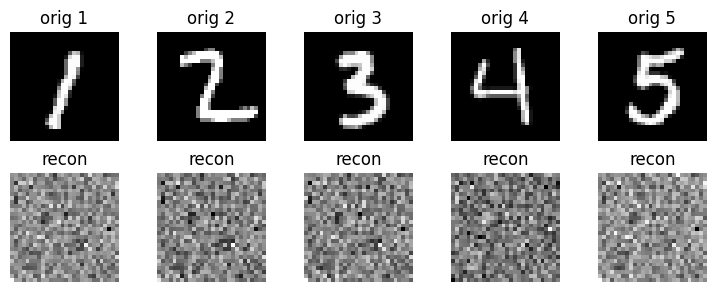

[mlp] Label not-a の例 (mlp)


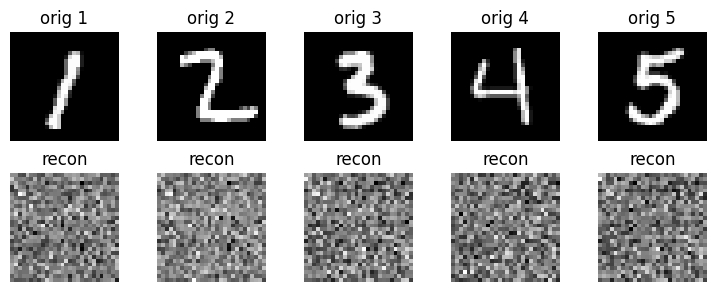

[proc] Label not-a の例 (proc)


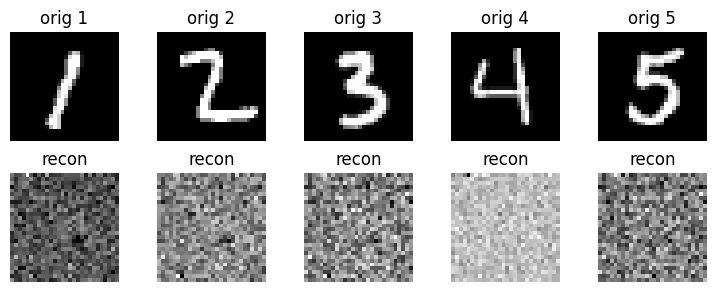

[pinv_orth] Label not-a の例 (pinv_orth)


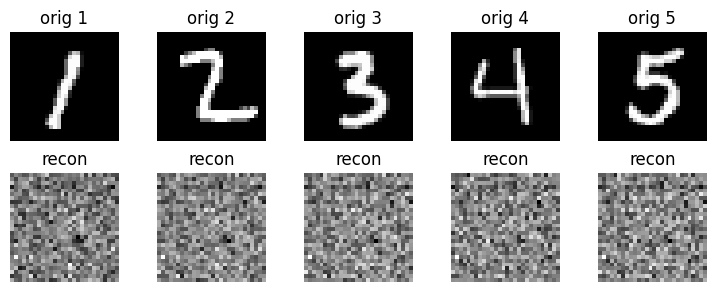

[pinv_not_orth] Label not-a の例 (pinv_not_orth)


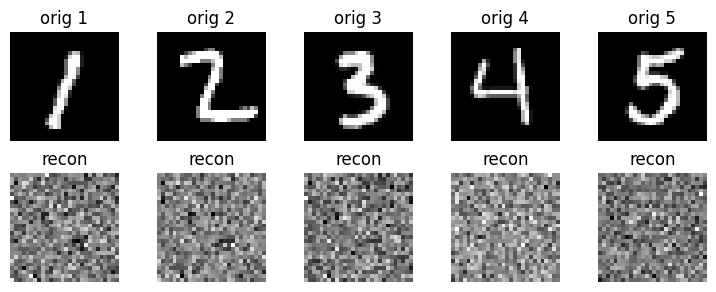

[anchor_local_leak] dataset=mnist, F_type=svd, dim=10, anchors=10, a_label=0, spill_type=random
  pseudo-inverse ACC   : all=0.1100, a=0.0833, not_a=0.1136
  MLP ACC              : all=0.1500, a=0.0000, not_a=0.1705
  Procrustes ACC       : all=0.1500, a=0.3333, not_a=0.1250
  pinv_orth ACC        : all=0.0700, a=0.0000, not_a=0.0795
  pinv_not_orth ACC    : all=0.1800, a=0.0833, not_a=0.1932
  pseudo-inverse RMSE  : all=2616.0458, a=3569.2158, not_a=2457.5902
  MLP RMSE             : all=131.0213, a=140.3766, not_a=129.6933
  Procrustes RMSE      : all=105.0909, a=129.1665, not_a=101.3658
  pinv_orth RMSE       : all=84.1732, a=100.2565, not_a=81.7352
  pinv_not_orth RMSE   : all=1834.8184, a=2244.4963, not_a=1771.6283
UMAP seed: 0


/Users/suetake/git-repos/takano_labo/dca/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[pinv] Label not-a の例 (pinv)


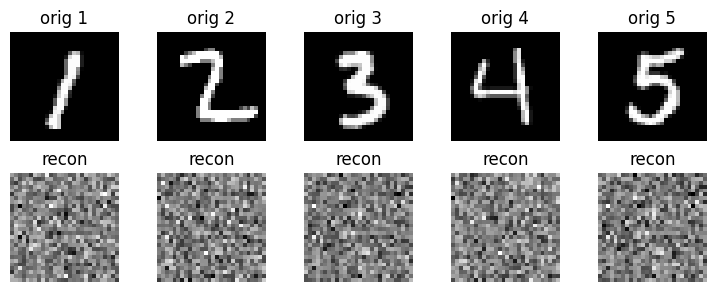

[mlp] Label not-a の例 (mlp)


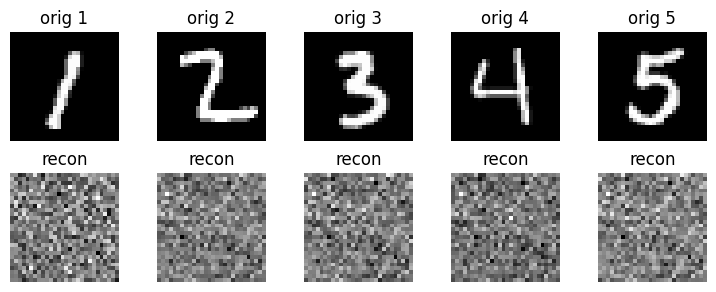

[proc] Label not-a の例 (proc)


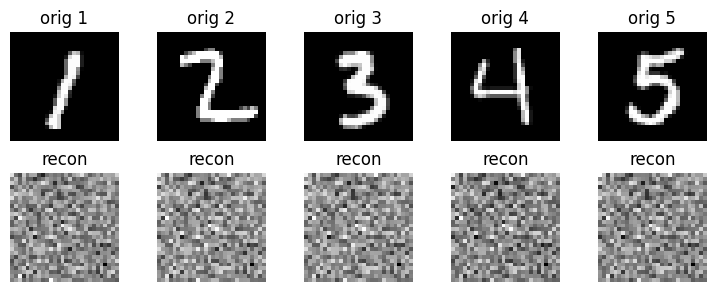

[pinv_orth] Label not-a の例 (pinv_orth)


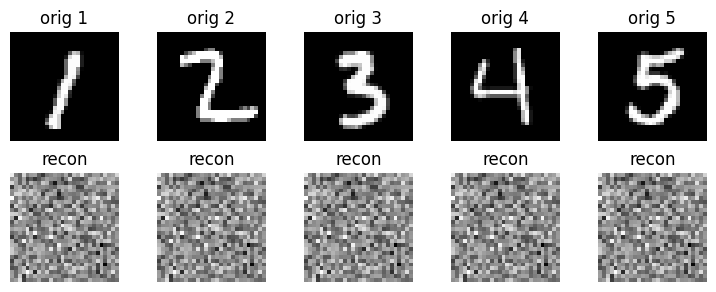

[pinv_not_orth] Label not-a の例 (pinv_not_orth)


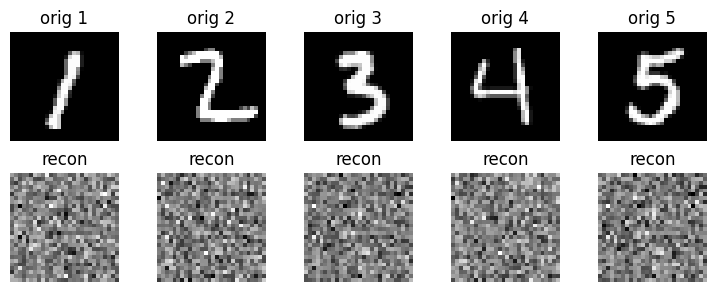

[anchor_local_leak] dataset=mnist, F_type=umap, dim=10, anchors=10, a_label=0, spill_type=random
  pseudo-inverse ACC   : all=0.0800, a=0.0833, not_a=0.0795
  MLP ACC              : all=0.2000, a=1.0000, not_a=0.0909
  Procrustes ACC       : all=0.0900, a=0.4167, not_a=0.0455
  pinv_orth ACC        : all=0.1200, a=0.0000, not_a=0.1364
  pinv_not_orth ACC    : all=0.0800, a=0.0833, not_a=0.0795
  pseudo-inverse RMSE  : all=1685.0313, a=1714.5496, not_a=1680.9659
  MLP RMSE             : all=84.5520, a=100.8056, not_a=82.0867
  Procrustes RMSE      : all=84.5795, a=100.7872, not_a=82.1219
  pinv_orth RMSE       : all=84.5795, a=100.7860, not_a=82.1222
  pinv_not_orth RMSE   : all=1685.0313, a=1714.5496, not_a=1680.9659


In [ ]:
from config.config import Config

base_config_dict = {
    "name": ["tutorial_mnist"],
    "dataset": [
    #"fashion_mnist",
    "mnist",
    #"mnist_1248",
    #"mice",
    #"statlog",
    #"qsar",
    #"digits",
    #"breast_cancer",
    #"adult",
    #"glass", 
    #"seeds", 
    #"letter_recognition",
    #"wine_quality",
    #"har",
    #"cifar10",
    #'3D_gaussian_clusters',
    #"concentric_three_circles",
    #"iris",
    #"ecoli",
    #"vowel"
    #"medmnist_3",
    #"medmnist_5"
],
    "spill_type": ["random"], # "local", "even", 
    "y_name": ["target"],
    "num_institution_user": [100],
    "data_distribution": ["even"],
    "anchor_method": ["gaussian"], # "smote"
    "num_anchor_data": [10],
    "dim_intermediate": [10],
    "F_type": ["svd", "umap"], #   "ae", "kernel_pca_self_tuning", "umap"
    "inter_normalization": [False],
    "preprocess":[False],
    "smote_ratio": [0],
    "gamma_ratio": [1.0],
    "seed":[i for i in range(1)],
    "visualize_rec": [True],
    "public_anchor_num": [100], #############
    #"use_public_anchor":[False],
}

df_results = run_anchor_local_leak_grid(base_config_dict)
df_results
# 適当な CSV 出力
df_results.to_csv("anchor_local_leak_results.csv", index=False)


[pinv] Label not-a の例 (pinv)


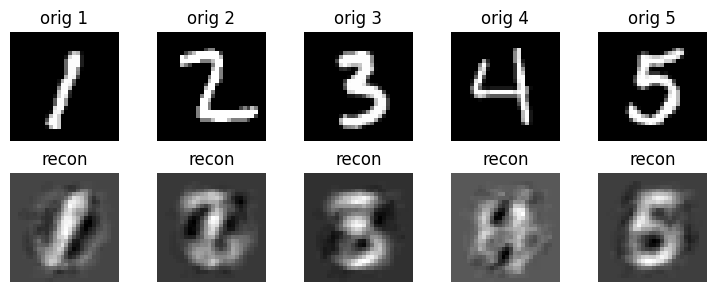

[mlp] Label not-a の例 (mlp)


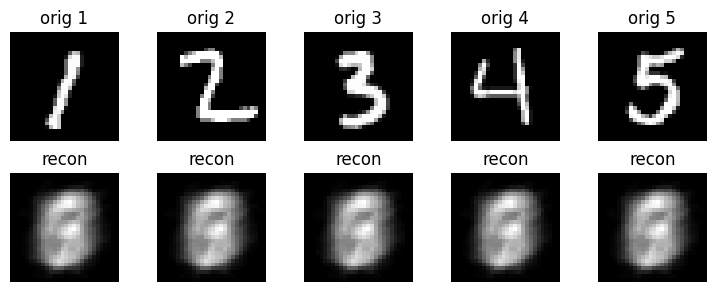

[proc] Label not-a の例 (proc)


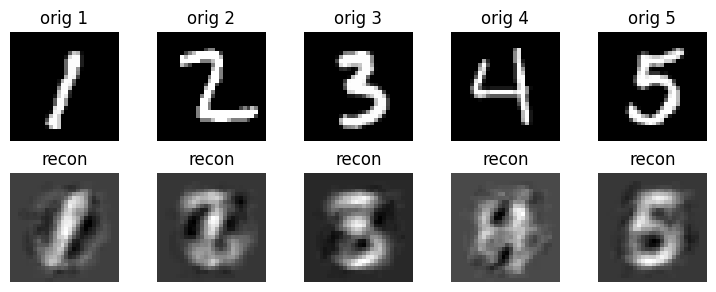

[pinv_orth] Label not-a の例 (pinv_orth)


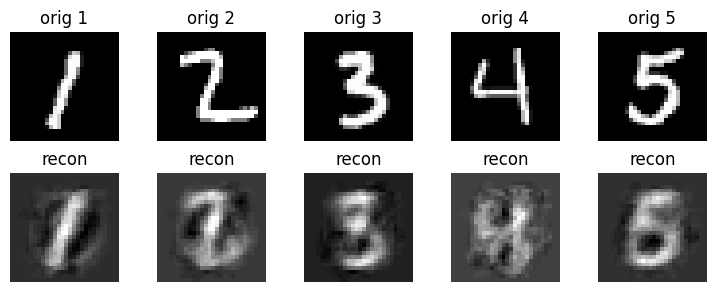

[pinv_not_orth] Label not-a の例 (pinv_not_orth)


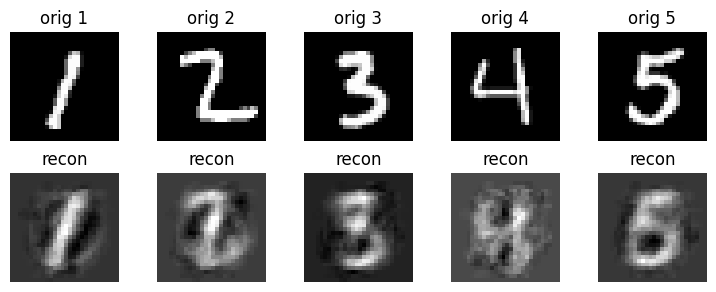

[anchor_local_leak] dataset=mnist, F_type=svd, dim=10, anchors=100, a_label=0, spill_type=random
  pseudo-inverse ACC   : all=0.7500, a=0.8333, not_a=0.7386
  MLP ACC              : all=0.1200, a=0.0000, not_a=0.1364
  Procrustes ACC       : all=0.7500, a=0.8333, not_a=0.7386
  pinv_orth ACC        : all=0.7200, a=0.8333, not_a=0.7045
  pinv_not_orth ACC    : all=0.7400, a=0.8333, not_a=0.7273
  pseudo-inverse RMSE  : all=50.6882, a=50.8950, not_a=50.6600
  MLP RMSE             : all=66.0300, a=77.4314, not_a=64.3189
  Procrustes RMSE      : all=49.4217, a=49.2853, not_a=49.4403
  pinv_orth RMSE       : all=46.3867, a=46.1687, not_a=46.4163
  pinv_not_orth RMSE   : all=46.6401, a=46.5207, not_a=46.6563


In [ ]:
from config.config import Config

base_config_dict = {
    "name": ["tutorial_mnist"],
    "dataset": [
    #"fashion_mnist",
    "mnist",
    #"mnist_1248",
    #"mice",
    #"statlog",
    #"qsar",
    #"digits",
    #"breast_cancer",
    #"adult",
    #"glass", 
    #"seeds", 
    #"letter_recognition",
    #"wine_quality",
    #"har",
    #"cifar10",
    #'3D_gaussian_clusters',
    #"concentric_three_circles",
    #"iris",
    #"ecoli",
    #"vowel"
    #"medmnist_3",
    #"medmnist_5"
],
    "spill_type": ["random"], # "local", "even", 
    "y_name": ["target"],
    "num_institution_user": [100],
    "data_distribution": ["even"],
    "anchor_method": ["smote"], # "smote"
    "num_anchor_data": [100],
    "dim_intermediate": [10],
    "F_type": ["svd"], #   "ae", "kernel_pca_self_tuning", "umap"
    "inter_normalization": [False],
    "preprocess":[False],
    "smote_ratio": [0],
    "gamma_ratio": [1.0],
    "seed":[i for i in range(1)],
    "visualize_rec": [True],
    "public_anchor_num": [100], #############
    "use_public_anchor":[False],
}

df_results = run_anchor_local_leak_grid(base_config_dict)
df_results
# 適当な CSV 出力
df_results.to_csv("anchor_local_leak_results.csv", index=False)
